In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('foodhub_order.csv')
dataset.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [3]:
dataset.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [4]:
dataset.sample(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
647,1477542,59673,Shake Shack,American,12.08,Weekday,Not given,27,27
1443,1478300,175703,The Meatball Shop,Italian,6.06,Weekend,Not given,20,27
739,1476887,142356,Blue Ribbon Sushi,Japanese,12.13,Weekday,Not given,26,27
901,1476658,127149,P.J. Clarke's,American,31.43,Weekend,4,31,23
367,1477360,91907,Sarabeth's Restaurant,American,12.08,Weekend,Not given,28,26


In [5]:
dataset.shape

(1898, 9)

In [6]:
dataset.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='object')

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [8]:
dataset.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [9]:
dataset.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [10]:
dataset = dataset.drop(columns= ['order_id'])
dataset.head()

,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [11]:
dataset['restaurant_name'].unique()

array(['Hangawi', 'Blue Ribbon Sushi Izakaya', 'Cafe Habana',
       'Blue Ribbon Fried Chicken', 'Dirty Bird to Go',
       'Tamarind TriBeCa', 'The Meatball Shop', 'Barbounia',
       'Anjappar Chettinad', 'Bukhara Grill',
       'Big Wong Restaurant \x8c_¤¾Ñ¼', 'Empanada Mama (closed)', 'Pylos',
       "Lucky's Famous Burgers", 'Shake Shack', 'Sushi of Gari',
       'RedFarm Hudson', 'Blue Ribbon Sushi',
       'Five Guys Burgers and Fries', 'Tortaria', 'Cafe Mogador',
       'Otto Enoteca Pizzeria', 'Vezzo Thin Crust Pizza',
       'Sushi of Gari 46', 'The Kati Roll Company', 'Klong',
       '5 Napkin Burger', 'TAO', 'Parm', 'Sushi Samba',
       'Haru Gramercy Park', 'Chipotle Mexican Grill $1.99 Delivery',
       'RedFarm Broadway', 'Cafeteria', 'DuMont Burger',
       "Sarabeth's East", 'Hill Country Fried Chicken', 'Bistango',
       "Jack's Wife Freda", "Mamoun's Falafel", 'Prosperity Dumpling',
       'Blue Ribbon Sushi Bar & Grill', 'Westville Hudson',
       'Blue Ribbon Br

In [12]:
dataset['restaurant_name'].str.replace(r"[a-zA-Z.]", "", regex= True).unique()

array(['', '   ', ' ', '  ', '   \x8c_¤¾Ñ¼', '  ()', "'  ", '    ',
       '   46', '5  ', '   $199 ', "' ", '    & ', "'  \x8e_À\x8eü£¾÷´",
       'Ì© ', '   & ', " '", ' 49', "'", '-', '    ()', "'   &  ", '- ',
       '! ! !', '12 ', '67 ', 'Ì±', " & '", '  2000 '], dtype=object)

In [13]:
dataset['restaurant_name'] = (
    dataset['restaurant_name']
    .astype(str)
    .str.replace(r"[\x8c_¤¾Ñ¼']", "", regex=True)
    .str.replace(r"[\x8e_À\x8eü£¾÷´]", "", regex=True)
    .str.replace(r"[-()$!Ì©Ì±,]", "", regex=True)
    .str.replace(r"[4651927000]", "", regex=True)
    .str.replace(r"closed", "", regex=True)
    .str.replace(r". Delivery", "", regex=True)
    .str.replace(r"LExpress", "Lexpress", regex=True)
    .str.replace(r"Tamarind TriBeCa", "Tamarind Tribeca", regex=True)
    .str.strip()
)
dataset['restaurant_name'].unique()

array(['Hangawi', 'Blue Ribbon Sushi Izakaya', 'Cafe Habana',
       'Blue Ribbon Fried Chicken', 'Dirty Bird to Go',
       'Tamarind Tribeca', 'The Meatball Shop', 'Barbounia',
       'Anjappar Chettinad', 'Bukhara Grill', 'Big Wong Restaurant',
       'Empanada Mama', 'Pylos', 'Luckys Famous Burgers', 'Shake Shack',
       'Sushi of Gari', 'RedFarm Hudson', 'Blue Ribbon Sushi',
       'Five Guys Burgers and Fries', 'Tortaria', 'Cafe Mogador',
       'Otto Enoteca Pizzeria', 'Vezzo Thin Crust Pizza',
       'The Kati Roll Company', 'Klong', 'Napkin Burger', 'TAO', 'Parm',
       'Sushi Samba', 'Haru Gramercy Park', 'Chipotle Mexican Grill',
       'RedFarm Broadway', 'Cafeteria', 'DuMont Burger', 'Sarabeths East',
       'Hill Country Fried Chicken', 'Bistango', 'Jacks Wife Freda',
       'Mamouns Falafel', 'Prosperity Dumpling',
       'Blue Ribbon Sushi Bar & Grill', 'Westville Hudson',
       'Blue Ribbon Brooklyn', 'Nobu Next Door', 'Osteria Morini',
       'Haandi', 'Benihana', 

In [14]:
dataset['cuisine_type'].unique()

array(['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese'], dtype=object)

In [15]:
dataset['day_of_the_week'].unique()

array(['Weekend', 'Weekday'], dtype=object)

In [16]:
dataset['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [17]:
dataset['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

In [18]:
dataset['rating'] = pd.to_numeric(dataset['rating'], errors= 'coerce')
dataset['rating'].dtype

dtype('float64')

In [19]:
dataset['rating'].value_counts()

rating
5.0    588
4.0    386
3.0    188
Name: count, dtype: int64

In [20]:
dataset['rating'].mode()[0]

np.float64(5.0)

In [21]:
dataset['rating']= dataset['rating'].fillna(dataset['rating'].mode()[0])

In [22]:
dataset['rating']= dataset['rating'].astype(int)
dataset.sample(5)

,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1439,108659,Osteria Morini,Italian,24.20,Weekday,3,28,28
566,60052,RedFarm Broadway,Chinese,12.61,Weekend,5,28,21
1108,35309,Blue Ribbon Sushi,Japanese,19.40,Weekend,5,24,25
1684,58088,Sushi of Gari,Japanese,12.18,Weekday,5,24,26
26,371590,The Meatball Shop,Italian,21.88,Weekday,5,24,27


In [23]:
dataset['rating'].unique()

array([5, 3, 4])

In [24]:
dataset['food_preparation_time'].unique()

array([25, 23, 20, 28, 33, 21, 29, 34, 24, 30, 35, 32, 31, 27, 22, 26])

In [25]:
dataset['delivery_time'].unique()

array([20, 23, 28, 15, 24, 21, 30, 26, 22, 17, 25, 16, 29, 27, 18, 31, 32,
       19, 33])

In [26]:
dataset.isnull().sum()

customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [27]:
dataset.duplicated().sum()

np.int64(0)

In [28]:
most_ordered_resturant= dataset['restaurant_name'].value_counts()
most_ordered_resturant

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Sushi Choshi                   1
Dos Caminos Soho               1
La Follia                      1
Philippe Chow                  1
wichcraft                      1
Name: count, Length: 177, dtype: int64

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64


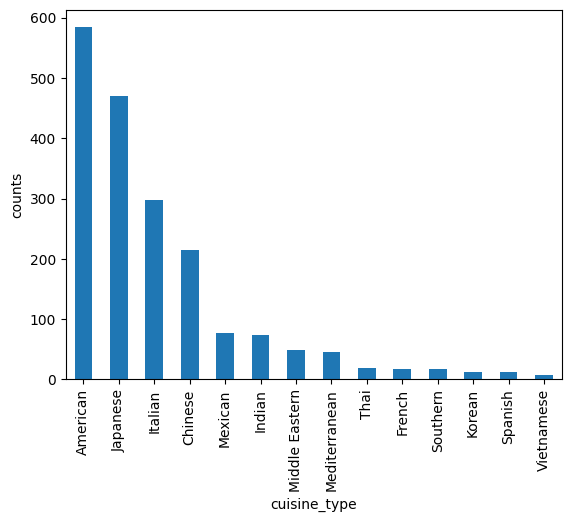

In [29]:
most_order_cuisine_type= dataset['cuisine_type'].value_counts()
print(most_order_cuisine_type)
most_order_cuisine_type.plot(kind= 'bar')
plt.xlabel('cuisine_type')
plt.ylabel('counts')
plt.show()

In [30]:
often_order_amount = dataset['cost_of_the_order'].value_counts()
print(often_order_amount)

cost_of_the_order
12.18    86
12.13    82
12.23    47
24.20    42
29.10    37
         ..
5.48      1
17.07     1
6.26      1
9.61      1
29.59     1
Name: count, Length: 312, dtype: int64


In [31]:
highest_order_amount = dataset['cost_of_the_order'].max()
print(highest_order_amount)

highest_order__amount_row = dataset[dataset['cost_of_the_order'] == highest_order_amount]
highest_order__amount_row

35.41


,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
573,62359,Pylos,Mediterranean,35.41,Weekday,4,21,29


In [32]:
lowest_order = dataset['cost_of_the_order'].min()
print(lowest_order)

lowest_order_row = dataset[dataset['cost_of_the_order'] == lowest_order]
lowest_order_row

4.47


,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
624,52327,Nobu Next Door,Japanese,4.47,Weekend,5,28,26


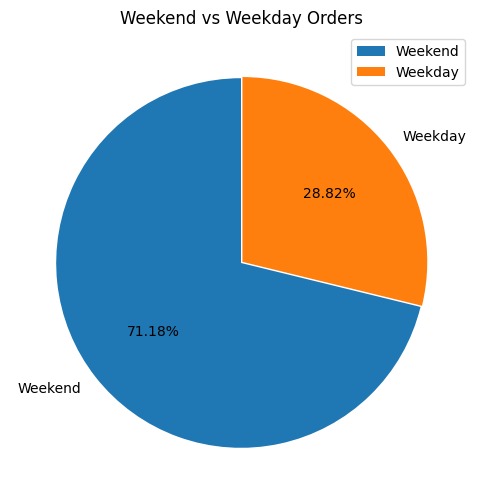

In [33]:
day_of_the_week = dataset['day_of_the_week'].value_counts()
plt.figure(figsize= (7, 6))
day_of_the_week.plot(kind= 'pie', autopct= '%1.2f%%', startangle= 90, explode= [0, 0.01])
plt.title('Weekend vs Weekday Orders')
plt.ylabel('')
plt.legend()
plt.show()

rating
5    1324
4     386
3     188
Name: count, dtype: int64


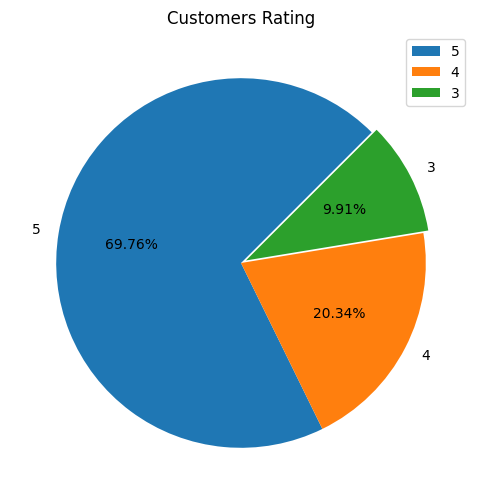

In [34]:
customers_rating = dataset['rating'].value_counts()
print(customers_rating)
plt.figure(figsize= (7, 6))
customers_rating.plot(kind= 'pie', autopct= '%1.2f%%', startangle= 45, explode= [0, 0, 0.03])
plt.title('Customers Rating')
plt.ylabel('')
plt.legend()
plt.show()

In [35]:
max_preparation_time = dataset['food_preparation_time'].max()
print('Maximum time to prepare food:', max_preparation_time)
print()

min_preparation_time = dataset['food_preparation_time'].min()
print('Minimum time to prepare food:', min_preparation_time)
print()

average_preparation_time = dataset['food_preparation_time'].mean()
print('Average food preparation time:', average_preparation_time)

Maximum time to prepare food: 35

Minimum time to prepare food: 20

Average food preparation time: 27.371970495258168


In [36]:
max_delivery_time = dataset['delivery_time'].max()
print('Maximum delivery time:', max_delivery_time)
print()

min_delivery_time = dataset['delivery_time'].min()
print('Minimum delivery time', min_delivery_time)
print()

average_delivery_time = dataset['delivery_time'].mean()
print('Average delivery time:', average_delivery_time)

Maximum delivery time: 33

Minimum delivery time 15

Average delivery time: 24.161749209694417


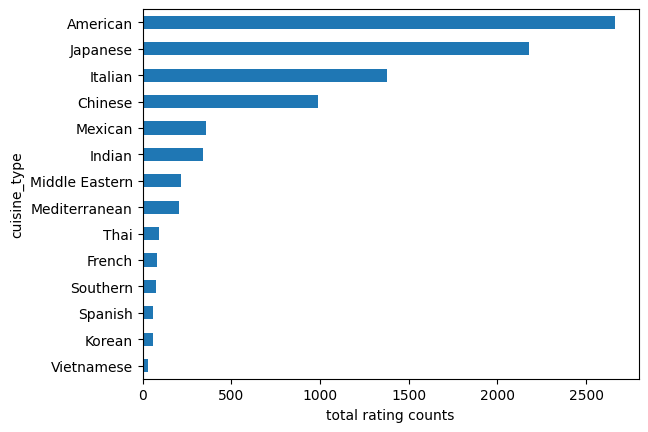

In [37]:
total_rating_by_cuisine_type = dataset.groupby('cuisine_type')['rating'].sum().sort_values(ascending= True)
total_rating_by_cuisine_type.plot(kind= 'barh')
plt.xlabel('total rating counts')
plt.show()

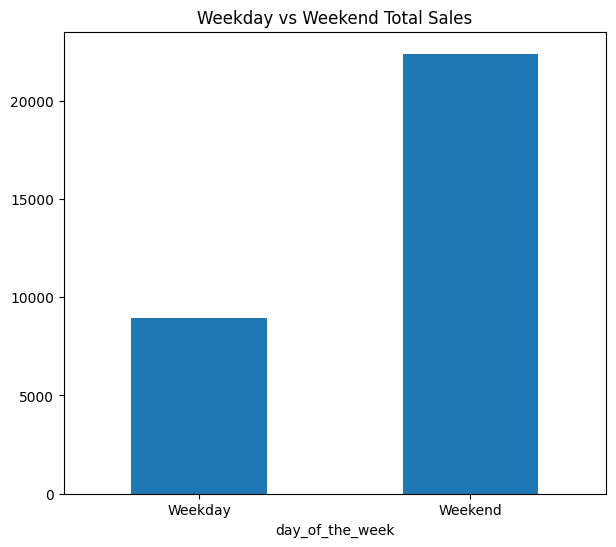

In [38]:
total_sales = dataset.groupby('day_of_the_week')['cost_of_the_order'].sum()
plt.figure(figsize= (7,6))
total_sales.plot(kind= 'bar')
plt.title('Weekday vs Weekend Total Sales')
plt.xticks(rotation= 0)
plt.show()

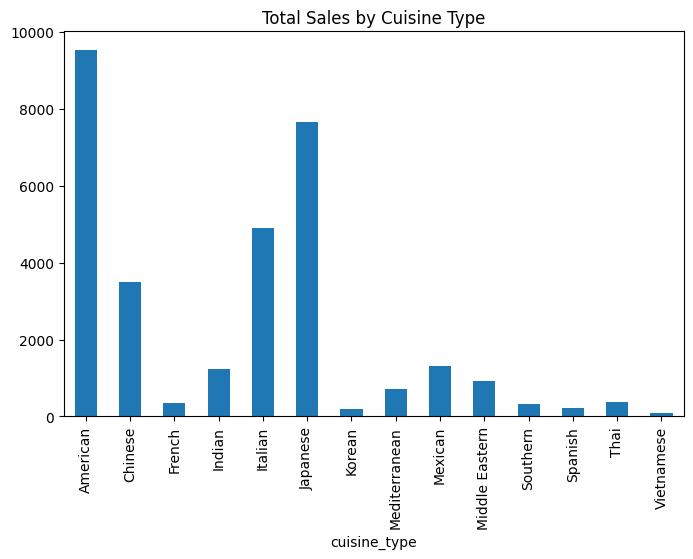

In [39]:
total_sales_by_cuisine_type = dataset.groupby('cuisine_type')['cost_of_the_order'].sum()
plt.figure(figsize= (8, 5))
total_sales_by_cuisine_type.plot(kind= 'bar')
plt.title('Total Sales by Cuisine Type')
plt.show()